**IMPORT LIBRARIES**

In [1]:
import sys
sys.path.append("../")

from src.puf_models import (
    generate_challenges,
    challenge_to_phi,
    generate_xor_response,
    generate_xor_response_with_noise
)


In [2]:
from src.attack_models import (
    logistic_attack,
    mlp_attack
)


In [1]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# This cell imports all libraries required for:
# - PUF simulation
# - Machine learning attacks
# - Data splitting
# - Visualization
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier


**DEFINE CORE PUF FUNCTIONS**


In [2]:
# ============================================================
# CORE PUF SIMULATION FUNCTIONS
# This section defines:
# 1. Challenge generation
# 2. Feature transformation (Phi vector)
# 3. Device weight generation
# 4. XOR Arbiter PUF response generation
# ============================================================


# Generate random binary challenges
def generate_challenges(num_samples, num_stages):
    return np.random.randint(0, 2, size=(num_samples, num_stages))


# Convert raw challenge bits into feature vector Phi
# This transformation makes Arbiter PUF linearly separable
def challenge_to_phi(challenges):
    num_samples, num_stages = challenges.shape
    phi = np.ones((num_samples, num_stages))

    for i in range(num_samples):
        for j in range(num_stages):
            product = 1
            for k in range(j, num_stages):
                product *= (1 - 2 * challenges[i][k])
            phi[i][j] = product

    return phi


# Generate random delay weights (represents manufacturing variations)
def generate_weights(num_stages):
    return np.random.randn(num_stages)


# Generate XOR Arbiter PUF response
# num_xor controls complexity of architecture
def generate_xor_response(phi, num_xor):
    num_samples, num_stages = phi.shape
    
    # Create independent weight vectors
    weight_list = [generate_weights(num_stages) for _ in range(num_xor)]
    
    all_responses = []

    # Compute response of each Arbiter
    for weights in weight_list:
        delays = np.dot(phi, weights)
        responses = (delays > 0).astype(int)
        all_responses.append(responses)

    # XOR combine outputs
    xor_response = all_responses[0]
    for i in range(1, num_xor):
        xor_response = np.logical_xor(xor_response, all_responses[i]).astype(int)

    return xor_response


**DEFINE CRP SCALING EXPERIMENT**

In [3]:
# ============================================================
# CRP SCALING EXPERIMENT
# This experiment studies how attack accuracy changes
# as the number of available Challenge-Response Pairs (CRPs) increases.
#
# It compares:
# - Linear attack (Logistic Regression)
# - Non-linear attack (MLP Neural Network)
# ============================================================

def crp_scaling_experiment(crp_list, num_stages=32, num_xor=3):

    linear_acc = []
    mlp_acc = []

    for crp_count in crp_list:

        # -------------------------------
        # Generate synthetic CRP dataset
        # -------------------------------
        X_challenges = generate_challenges(crp_count, num_stages)
        X_phi = challenge_to_phi(X_challenges)
        y = generate_xor_response(X_phi, num_xor)

        # -------------------------------
        # Split into train and test sets
        # -------------------------------
        X_train, X_test, y_train, y_test = train_test_split(
            X_phi, y, test_size=0.3, random_state=42
        )

        # -------------------------------
        # Linear Modeling Attack
        # -------------------------------
        lin_model = LogisticRegression(max_iter=1000)
        lin_model.fit(X_train, y_train)
        y_pred_lin = lin_model.predict(X_test)
        linear_acc.append(accuracy_score(y_test, y_pred_lin))

        # -------------------------------
        # Non-linear Neural Network Attack
        # -------------------------------
        mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=200)
        mlp.fit(X_train, y_train)
        y_pred_mlp = mlp.predict(X_test)
        mlp_acc.append(accuracy_score(y_test, y_pred_mlp))

        print(f"CRPs: {crp_count} completed")

    return linear_acc, mlp_acc


**RUN EXPERIMENTS AND PLOT RESULTS**

C:\Users\divis\PUF_ML_PROJECT\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


CRPs: 1000 completed


C:\Users\divis\PUF_ML_PROJECT\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


CRPs: 5000 completed
CRPs: 10000 completed
CRPs: 20000 completed
CRPs: 50000 completed


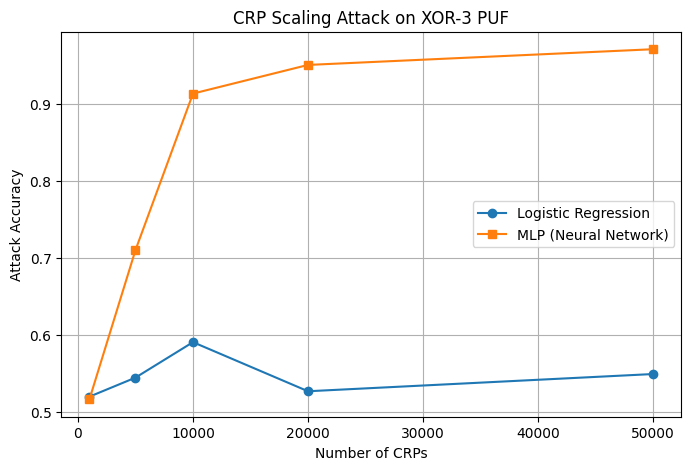

In [4]:
# ============================================================
# RUN CRP SCALING EXPERIMENT
# We evaluate how modeling accuracy changes as
# more CRPs are available to the attacker.
# ============================================================

crp_list = [1000, 5000, 10000, 20000, 50000]

linear_acc, mlp_acc = crp_scaling_experiment(crp_list, num_xor=3)


# -------------------------------
# Plot Results
# -------------------------------

plt.figure(figsize=(8,5))
plt.plot(crp_list, linear_acc, marker='o', label="Logistic Regression")
plt.plot(crp_list, mlp_acc, marker='s', label="MLP (Neural Network)")
plt.xlabel("Number of CRPs")
plt.ylabel("Attack Accuracy")
plt.title("CRP Scaling Attack on XOR-3 PUF")
plt.legend()
plt.grid(True)
plt.show()


In [5]:
# ============================================================
# XOR-ORDER SCALING EXPERIMENT
# This experiment evaluates how modeling accuracy changes
# as XOR complexity increases.
# ============================================================

def xor_order_experiment(xor_list, crp_count=20000, num_stages=32):

    linear_acc = []
    mlp_acc = []

    for xor_order in xor_list:

        # Generate dataset
        X_challenges = generate_challenges(crp_count, num_stages)
        X_phi = challenge_to_phi(X_challenges)
        y = generate_xor_response(X_phi, xor_order)

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X_phi, y, test_size=0.3, random_state=42
        )

        # Linear attack
        lin_model = LogisticRegression(max_iter=1000)
        lin_model.fit(X_train, y_train)
        y_pred_lin = lin_model.predict(X_test)
        linear_acc.append(accuracy_score(y_test, y_pred_lin))

        # MLP attack
        mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=300)
        mlp.fit(X_train, y_train)
        y_pred_mlp = mlp.predict(X_test)
        mlp_acc.append(accuracy_score(y_test, y_pred_mlp))

        print(f"XOR-{xor_order} completed")

    return linear_acc, mlp_acc


**RUN THE EXPERIMENT**

XOR-1 completed
XOR-2 completed
XOR-3 completed


C:\Users\divis\PUF_ML_PROJECT\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


XOR-4 completed
XOR-5 completed


C:\Users\divis\PUF_ML_PROJECT\venv\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


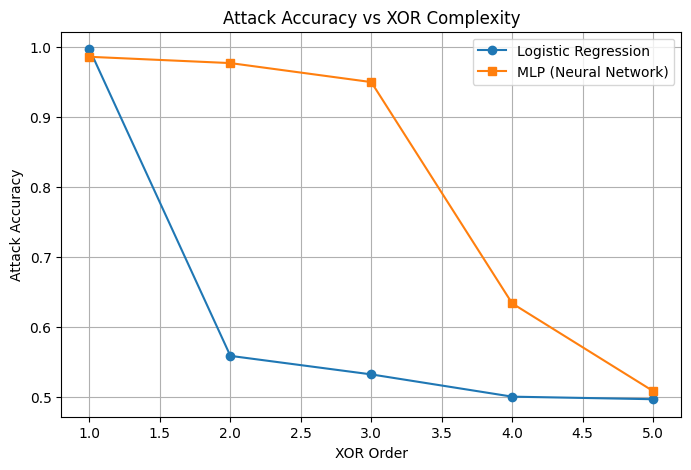

In [6]:
xor_list = [1, 2, 3, 4, 5]

linear_acc_xor, mlp_acc_xor = xor_order_experiment(xor_list)

plt.figure(figsize=(8,5))
plt.plot(xor_list, linear_acc_xor, marker='o', label="Logistic Regression")
plt.plot(xor_list, mlp_acc_xor, marker='s', label="MLP (Neural Network)")
plt.xlabel("XOR Order")
plt.ylabel("Attack Accuracy")
plt.title("Attack Accuracy vs XOR Complexity")
plt.legend()
plt.grid(True)
plt.show()


**MODIFY XOR FUNCTION TO ADD NOISE**

In [7]:
# ============================================================
# XOR PUF WITH NOISE
# Adds Gaussian noise to delay values before decision
# sigma controls noise strength
# ============================================================

def generate_xor_response_with_noise(phi, num_xor, sigma=0.1):

    num_samples, num_stages = phi.shape
    weight_list = [generate_weights(num_stages) for _ in range(num_xor)]
    
    all_responses = []

    for weights in weight_list:
        delays = np.dot(phi, weights)

        # Add Gaussian noise
        noise = np.random.normal(0, sigma, size=delays.shape)
        delays_noisy = delays + noise

        responses = (delays_noisy > 0).astype(int)
        all_responses.append(responses)

    xor_response = all_responses[0]
    for i in range(1, num_xor):
        xor_response = np.logical_xor(xor_response, all_responses[i]).astype(int)

    return xor_response


**NOISE SCALING EXPERIMENT**

In [8]:
# ============================================================
# NOISE ROBUSTNESS EXPERIMENT
# Evaluates attack accuracy under increasing noise levels
# ============================================================

def noise_experiment(sigma_list, crp_count=20000, num_stages=32, num_xor=3):

    mlp_acc = []

    for sigma in sigma_list:

        # Generate dataset
        X_challenges = generate_challenges(crp_count, num_stages)
        X_phi = challenge_to_phi(X_challenges)
        y = generate_xor_response_with_noise(X_phi, num_xor, sigma=sigma)

        # Split
        X_train, X_test, y_train, y_test = train_test_split(
            X_phi, y, test_size=0.3, random_state=42
        )

        # Train MLP attacker
        mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=400)
        mlp.fit(X_train, y_train)

        y_pred = mlp.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        mlp_acc.append(acc)

        print(f"Noise sigma: {sigma} completed")

    return mlp_acc


**RUN NOISE STUDY**

Noise sigma: 0 completed
Noise sigma: 0.05 completed
Noise sigma: 0.1 completed
Noise sigma: 0.2 completed
Noise sigma: 0.3 completed
Noise sigma: 0.5 completed


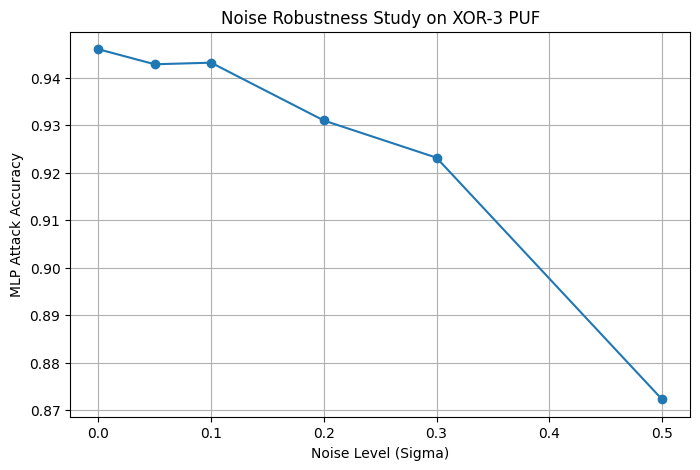

In [9]:
sigma_list = [0, 0.05, 0.1, 0.2, 0.3, 0.5]

noise_results = noise_experiment(sigma_list)

plt.figure(figsize=(8,5))
plt.plot(sigma_list, noise_results, marker='o')
plt.xlabel("Noise Level (Sigma)")
plt.ylabel("MLP Attack Accuracy")
plt.title("Noise Robustness Study on XOR-3 PUF")
plt.grid(True)
plt.show()


**STATISTICAL NOISE EXPERIMENT**

In [10]:
# ============================================================
# STATISTICAL NOISE EXPERIMENT (Mean ± Std)
# Runs multiple trials for each noise level
# ============================================================

def statistical_noise_experiment(sigma_list, runs=5, 
                                 crp_count=20000, 
                                 num_stages=32, 
                                 num_xor=3):

    mean_acc = []
    std_acc = []

    for sigma in sigma_list:

        run_accuracies = []

        for r in range(runs):

            # Generate dataset
            X_challenges = generate_challenges(crp_count, num_stages)
            X_phi = challenge_to_phi(X_challenges)
            y = generate_xor_response_with_noise(X_phi, num_xor, sigma=sigma)

            # Split
            X_train, X_test, y_train, y_test = train_test_split(
                X_phi, y, test_size=0.3, random_state=None
            )

            # Train MLP attacker
            mlp = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=400)
            mlp.fit(X_train, y_train)

            y_pred = mlp.predict(X_test)
            acc = accuracy_score(y_test, y_pred)

            run_accuracies.append(acc)

        mean_acc.append(np.mean(run_accuracies))
        std_acc.append(np.std(run_accuracies))

        print(f"Noise sigma {sigma} completed")

    return mean_acc, std_acc


**RUN STATISTICAL STUDY**

In [11]:
sigma_list = [0, 0.05, 0.1, 0.2, 0.3, 0.5]

mean_results, std_results = statistical_noise_experiment(sigma_list)


Noise sigma 0 completed
Noise sigma 0.05 completed
Noise sigma 0.1 completed
Noise sigma 0.2 completed
Noise sigma 0.3 completed
Noise sigma 0.5 completed


**PLOT WITH ERROR BARS**

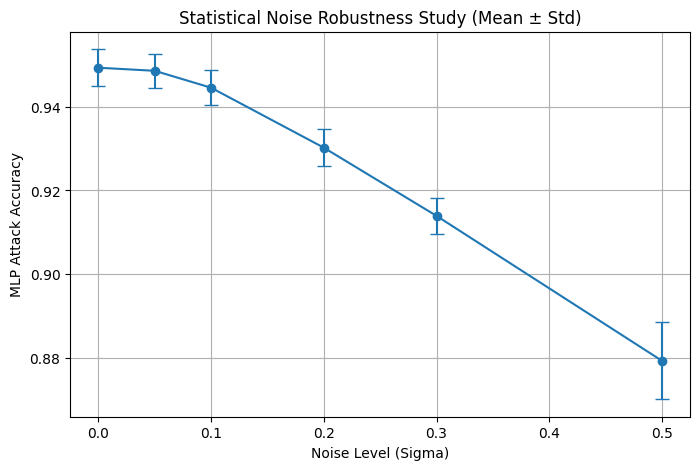

In [12]:
plt.figure(figsize=(8,5))
plt.errorbar(sigma_list, mean_results, yerr=std_results, 
             marker='o', capsize=5)

plt.xlabel("Noise Level (Sigma)")
plt.ylabel("MLP Attack Accuracy")
plt.title("Statistical Noise Robustness Study (Mean ± Std)")
plt.grid(True)
plt.show()